In [55]:
mamba install scikit-learn pandas seaborn matplotlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, scikit-learn, pandas, seaborn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.208 seconds
All requested packages already installed.


# KMeans Clustering Analysis

In [35]:
df = pd.read_csv("H-MERIDIANHEALTH_cleaned.csv")
df["readmitted"] = (df["readmission_30day"] == "Yes").astype(int)
df.head()

,patient_id,hospital_id,hospital_location_type,hospital_size_beds,admission_date,admission_type,primary_diagnosis,comorbidity_count,patient_age,length_of_stay_days,...,follow_up_scheduled,post_discharge_call_made,patient_education_provided,medication_reconciliation_completed,social_determinants_risk_score,insurance_type,ed_visits_past_year,readmission_30day,readmission_reason,readmitted
0,PT007060,HCA016,Urban,466,2023-01-01,Urgent,Orthopedic,2,78,5,...,Yes,Yes,Yes,Yes,7,Medicare,1,No,Not Applicable,0
1,PT008060,HCA018,Suburban,313,2023-01-01,Elective,Respiratory,2,41,8,...,Yes,Yes,No,Yes,4,Private,1,No,Not Applicable,0
2,PT007196,HCA007,Urban,342,2023-01-01,Elective,Respiratory,4,69,9,...,Yes,No,No,Yes,6,Medicare,4,Yes,Same Condition,1
3,PT000192,HCA006,Suburban,288,2023-01-01,Emergency,Respiratory,1,67,8,...,No,No,Yes,No,6,Medicaid,2,No,Not Applicable,0
4,PT003334,HCA044,Urban,336,2023-01-01,Emergency,Cardiovascular,3,60,9,...,Yes,No,No,Yes,9,Uninsured,1,Yes,Same Condition,1


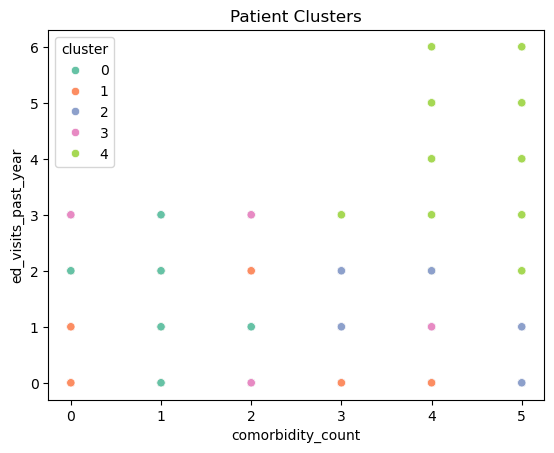

         patients  readmission_rate  avg_comorbidities    avg_age    avg_los  \
cluster                                                                        
4            1500          0.594000           4.015333  59.712667  10.304000   
2            1913          0.515421           2.889179  61.730789  11.141140   
0            2270          0.442291           1.418062  66.081498   6.186784   
1            2153          0.390153           1.351138  35.262889   6.739433   
3            2164          0.382625           1.553142  64.704713   6.336414   

         avg_ed_visits  
cluster                 
4             3.388000  
2             0.739676  
0             0.980617  
1             0.911751  
3             0.922366  


In [49]:
cluster_features = ["comorbidity_count", "patient_age", "length_of_stay_days",
                     "social_determinants_risk_score", "ed_visits_past_year"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_features])

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

sns.scatterplot(data=df, x="comorbidity_count", y="ed_visits_past_year", hue="cluster", palette="Set2")
plt.title("Patient Clusters")
plt.savefig("clusters.png")
plt.show()

cluster_summary = df.groupby("cluster").agg(
    patients=("patient_id", "count"),
    readmission_rate=("readmitted", "mean"),
    avg_comorbidities=("comorbidity_count", "mean"),
    avg_age=("patient_age", "mean"),
    avg_los=("length_of_stay_days", "mean"),
    avg_ed_visits=("ed_visits_past_year", "mean"),
).sort_values("readmission_rate", ascending=False)

print(cluster_summary)

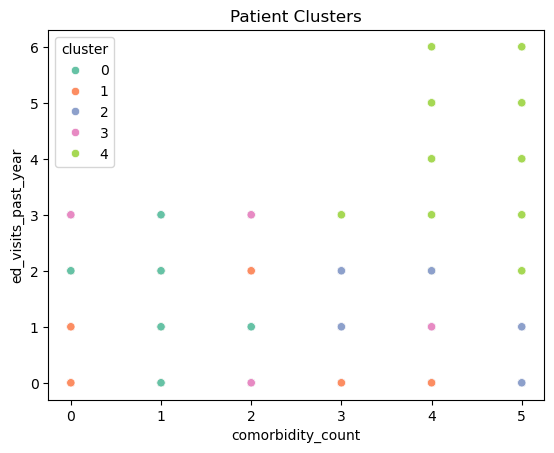

In [64]:
sns.scatterplot(data=df, x="comorbidity_count", y="ed_visits_past_year", hue="cluster", palette="Set2")
plt.title("Patient Clusters")
plt.savefig("clusters.png")
plt.show()

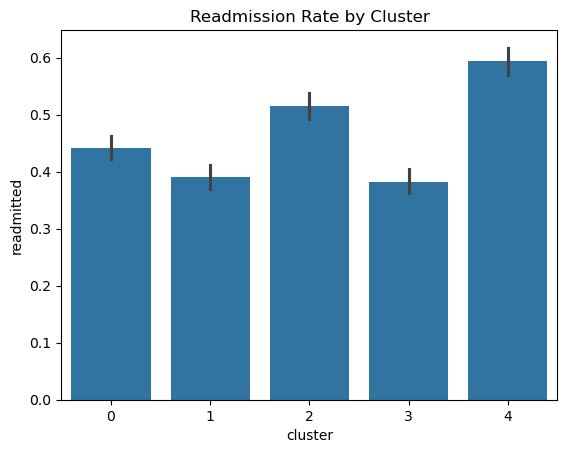

In [51]:
sns.barplot(data=df, x="cluster", y="readmitted")
plt.title("Readmission Rate by Cluster")
plt.savefig("cluster_readmission_rate.png")
plt.show()

# Logistic Regression

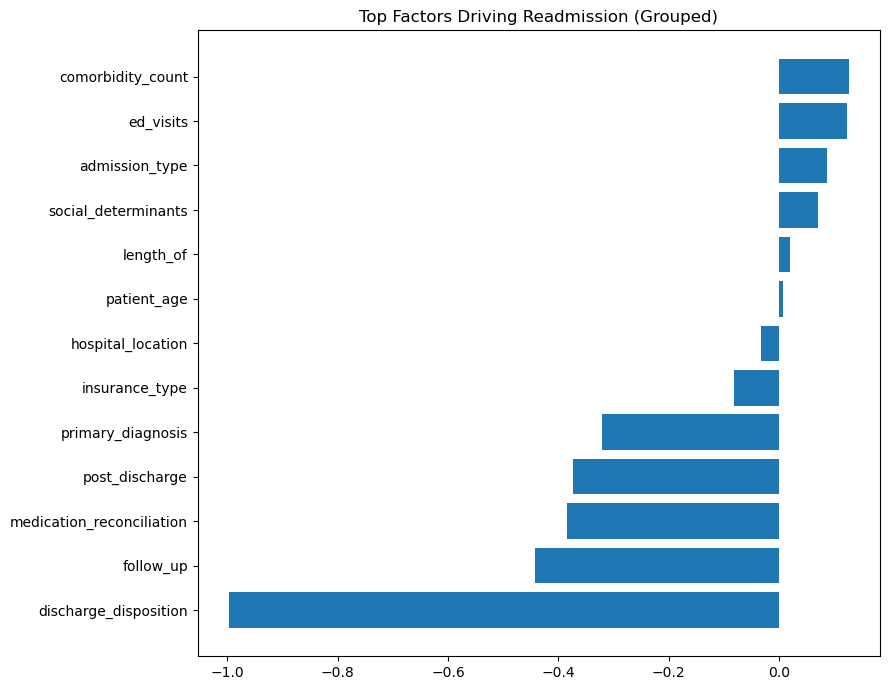

In [52]:
coef_df = pd.DataFrame({"feature": X.columns, "coefficient": logreg.coef_[0]})
coef_df["group"] = coef_df["feature"].str.split("_").str[0:2].str.join("_")
grouped = coef_df.groupby("group")["coefficient"].mean().sort_values()

plt.figure(figsize=(9, 7))
plt.barh(grouped.index, grouped.values)
plt.title("Top Factors Driving Readmission (Grouped)")
plt.tight_layout()
plt.savefig("logreg_importance.png")
plt.show()

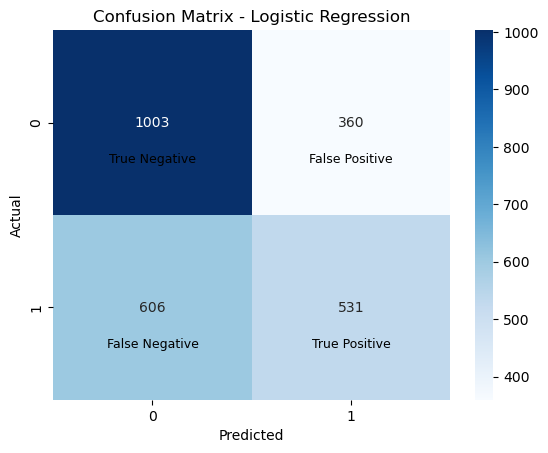

In [63]:
cm = confusion_matrix(y_test, y_pred)

labels = [["True Negative", "False Positive"], ["False Negative", "True Positive"]]

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

for i in range(2):
    for j in range(2):
        plt.text(j + 0.5, i + 0.7, labels[i][j], ha="center", va="center", fontsize=9, color="black")
        
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.savefig("confusion_matrix.png")
plt.show()

In [53]:
cat_features = ["admission_type", "primary_diagnosis", "discharge_disposition",
                "follow_up_scheduled", "post_discharge_call_made",
                "medication_reconciliation_completed", "insurance_type", "hospital_location_type"]
num_features = ["comorbidity_count", "patient_age", "length_of_stay_days",
                "social_determinants_risk_score", "ed_visits_past_year"]

X = pd.get_dummies(df[cat_features + num_features], columns=cat_features, drop_first=True)
y = df["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.74      0.67      1363
           1       0.60      0.47      0.52      1137

    accuracy                           0.61      2500
   macro avg       0.61      0.60      0.60      2500
weighted avg       0.61      0.61      0.61      2500



In [54]:
print("ROC AUC:", roc_auc_score(y_test, y_proba))

ROC AUC: 0.6506174297345797


In [42]:
coef_df = pd.DataFrame({"feature": X.columns, "coefficient": logreg.coef_[0]}).sort_values("coefficient")
print(coef_df.head(10))

                                           feature  coefficient
16     discharge_disposition_Home with Home Health    -1.115214
18  discharge_disposition_Skilled Nursing Facility    -1.049582
15                      discharge_disposition_Home    -0.922231
17            discharge_disposition_Rehab Facility    -0.903274
12                    primary_diagnosis_Orthopedic    -0.566504
8             primary_diagnosis_Diabetes/Endocrine    -0.516038
9               primary_diagnosis_Gastrointestinal    -0.509207
19                         follow_up_scheduled_Yes    -0.442189
10            primary_diagnosis_Infectious Disease    -0.422543
21         medication_reconciliation_completed_Yes    -0.384309


In [43]:
print(coef_df.tail(10))

                           feature  coefficient
1                      patient_age     0.006975
5         admission_type_Emergency     0.016008
2              length_of_stay_days     0.020950
7            admission_type_Urgent     0.031418
14   primary_diagnosis_Respiratory     0.043170
3   social_determinants_risk_score     0.070994
13         primary_diagnosis_Renal     0.092132
4              ed_visits_past_year     0.123913
0                comorbidity_count     0.127160
6            admission_type_Trauma     0.216957
